In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def node_label(position, cf, ctp):
  duration = 1
  return (position, duration, ctp, cf)

# change to position, note, duration

In [3]:
def make_cf_graph(melody):
  nodes = []
  edges = []
  for i in range(len(melody)):
    nodes.append((i, 1, melody[i]))
    if i > 0:
      edges.append(((i-1, 1, melody[i-1]), (i, 1, melody[i])))
      
  G = nx.DiGraph()
  G.add_nodes_from(nodes)
  G.add_edges_from(edges)
  
  return G


In [4]:
# only works with first species and ctp above
def make_ctp_graph(melody_data):
    melody = melody_data["melody"]
    final_index = len(melody) - 1
    
    all_possibilities = dict()
    
    nodes = list()
    final_nodes = list()
    first_nodes = list()
    edges = list()
    
    # find all possible nodes
    for i in range(0, len(melody)):
        note = melody[i]
        current = all_possibilities[i] = []
        
        # get possible counterpoint notes
        if i == 0 or i == final_index:
            possible_ctps = [note, note + 7, note + 12, note + 19]
        elif i == final_index - 1:
            if note > 0:
              possible_ctps = [note + 9]
            elif note < 0:
              possible_ctps = [note + 3, note + 3 + 12]
        else:
            possible_ctps = melody_data[str(note)]
        
        # add nodes for each possible ctp
        for ctp in possible_ctps:
            label = node_label(
                i, note, ctp
            )  # create label: "index, melody note, ctp note"
            current.append(ctp)  # add label to possibilities dictionary
            nodes.append(label)  # add label to nodes list
            if i == 0:
                first_nodes.append(label)
            if i == final_index:
                final_nodes.append(label)
                
    # find all possible edges
    for key, possibilities in all_possibilities.items():
      
        if key != final_index:
            note = melody[key]
            index = int(key)

            next_index = index + 1
            next_note = melody[next_index]
            next_possibilities = all_possibilities[next_index]

            for possibility in possibilities:
                label = node_label(index, note, possibility)
                for next_possibility in next_possibilities:
                    # check if move is valid, if so add edge
                    valid = first.is_valid_move(note, next_note, possibility, next_possibility)
                    if valid:
                        next_label = node_label(next_index, next_note, next_possibility)
                        edge = (label, next_label)
                        edges.append(edge)
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
  
    G = remove_unreachable_nodes(G)
    G = remove_unreaching_nodes(G, final_index)
    
    return G


## Pruning Functons

In [5]:
'''def find_start_and_end_nodes(graph):
    """
    Find all start nodes (nodes with no incoming edges) and end nodes (nodes with no outgoing edges).
    
    Parameters:
    - graph: The network represented as a directed graph.
    
    Returns:
    - start_nodes: List of start nodes.
    - end_nodes: List of end nodes.
    """
    start_nodes = [node for node in graph if graph.in_degree(node) == 0]
    end_nodes = [node for node in graph if graph.out_degree(node) == 0]
    return start_nodes, end_nodes

def remove_unreaching_nodes(graph):
    """
    Remove nodes that are not part of any path from any start node to any end node.

    Parameters:
    - graph: The network represented as a directed graph.
    """
    start_nodes, end_nodes = find_start_and_end_nodes(graph)

    if not start_nodes or not end_nodes:
        raise ValueError("No suitable start nodes or end nodes found in the network.")
    print(start_nodes)
    print(end_nodes)
    # Find all nodes reachable from any start node
    reachable_from_start = set()
    for start_node in start_nodes:
        reachable_from_start.update(nx.descendants(graph, start_node))
        reachable_from_start.add(start_node)

    # Find all nodes that can reach any end node
    reachable_to_end = set()
    for end_node in end_nodes:
        reachable_to_end.update(nx.ancestors(graph, end_node))
        reachable_to_end.add(end_node)

    # Nodes that are part of any path from any start node to any end node
    valid_nodes = reachable_from_start.intersection(reachable_to_end)

    # Ensure all start nodes and end nodes are included in the valid nodes
    valid_nodes.update(start_nodes)
    valid_nodes.update(end_nodes)

    # Remove nodes not in the valid_nodes set
    nodes_to_remove = set(graph.nodes()) - valid_nodes
    graph.remove_nodes_from(nodes_to_remove)
    
    return graph
'''

'def find_start_and_end_nodes(graph):\n    """\n    Find all start nodes (nodes with no incoming edges) and end nodes (nodes with no outgoing edges).\n    \n    Parameters:\n    - graph: The network represented as a directed graph.\n    \n    Returns:\n    - start_nodes: List of start nodes.\n    - end_nodes: List of end nodes.\n    """\n    start_nodes = [node for node in graph if graph.in_degree(node) == 0]\n    end_nodes = [node for node in graph if graph.out_degree(node) == 0]\n    return start_nodes, end_nodes\n\ndef remove_unreaching_nodes(graph):\n    """\n    Remove nodes that are not part of any path from any start node to any end node.\n\n    Parameters:\n    - graph: The network represented as a directed graph.\n    """\n    start_nodes, end_nodes = find_start_and_end_nodes(graph)\n\n    if not start_nodes or not end_nodes:\n        raise ValueError("No suitable start nodes or end nodes found in the network.")\n    print(start_nodes)\n    print(end_nodes)\n    # Find all nod

In [6]:
# remove all nodes unreachable from a first node
def remove_unreachable_nodes(graph):
    """
    Remove nodes from a NetworkX graph that are not on a path to any of the specified nodes.

    Args:
        G (nx.Graph or nx.DiGraph): The input graph.
        specified_nodes (list): List of nodes that are considered reachable.

    Returns:
        nx.Graph or nx.DiGraph: The modified graph with unreachable nodes removed.
    """
    # find first nodes
    nodes = list(graph.nodes())
    first_nodes = []
    for node in nodes:
      position = node[0]
      if position == 0:
        first_nodes.append(node)
      
    # Create a set of reachable nodes
    reachable_nodes = set(first_nodes)

    # Perform a breadth-first search from each specified node and add all reachable nodes to the set
    for node in first_nodes:
        reachable_nodes.update(nx.descendants(graph, node))

    # Get the set of nodes that are not reachable
    unreachable_nodes = set(graph.nodes()) - reachable_nodes

    # Remove the unreachable nodes from the graph
    graph.remove_nodes_from(unreachable_nodes)

    # Return the modified graph with unreachable nodes removed
    return graph


In [7]:
# remove nodes not on a path to a final node

def remove_unreaching_nodes(graph, final_index):
  """Remove nodes from a NetworkX graph that do not have a path to any of the
  nodes in the input array.

  Args:
      G (nx.Graph or nx.DiGraph): The input graph.
      nodes (list): List of nodes that are considered reachable.

  Returns:
      nx.Graph or nx.DiGraph: The modified graph with unreachable nodes removed.
  """
  # Create a list of last nodes
  nodes = list(graph.nodes())
  final_nodes = []
  for node in nodes:
    position = node[0]
    if position == final_index:
      final_nodes.append(node)
  on_path = [] 
  # add all nodes on a path to the end to on_path.
  print(final_nodes)
  while nodes:
    node = nodes.pop()
    is_on_path = None
    for final_node in final_nodes:
      if final_nodes.__contains__(node): # fixed from final_node to final_nodes
        is_on_path = True
        on_path.append(node)
      elif not is_on_path:
        descendants = (nx.descendants(graph, node))
        if descendants.__contains__(final_node):
          is_on_path = True
          on_path.append(node)
  
  # Create a set of all of the nodes that do not have
  # a path to any of the specified nodes.
  
  unreaching_nodes = set(graph.nodes()) - set(on_path)
  
  # Remove all of the unreaching nodes from the graph.
  for node in unreaching_nodes:
    graph.remove_node(node)
  
  return graph


In [8]:
def visualize_network(G):
  # Set the spring layout with custom node positions
  pos = nx.spring_layout(G, seed=42)

  #create dictionary of x-axis and y-axis indexes
  pos_nodes = G.nodes
  pos_node_x = {}
  pos_node_y = {}
  for node in pos_nodes:
    position = node[0]
    ctp = node[2]
    pos_node_y[node] = ctp
    pos_node_x[node] = (position, ctp)

  # Set custom x-axis positions for nodes
  for node, coords in pos_node_x.items():
    pos[node] = coords
  """or node, y in pos_node_y.items():
    pos[node][0] = y """
  
  # TODO create dictionary of y-axis positions for pitch classes
  
  nx.draw(G, pos, with_labels=True, arrows=True)
  plt.figure(figsize = (2^16,2^16))
  
  

imperfect
7
-7
perfect
False
[(6, 1, 12, 0), (6, 1, 19, 0)]


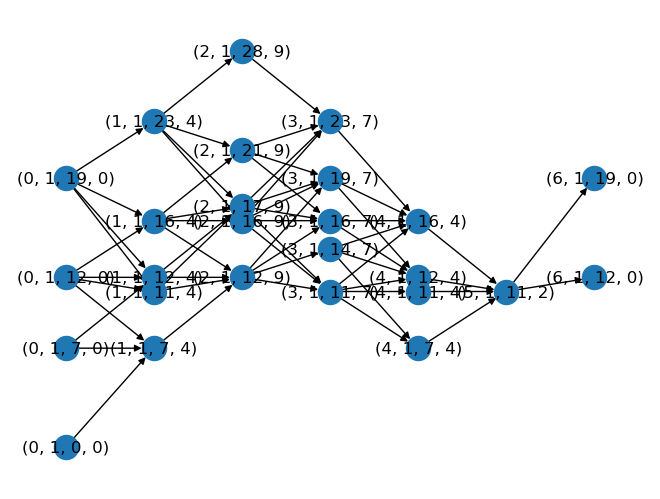

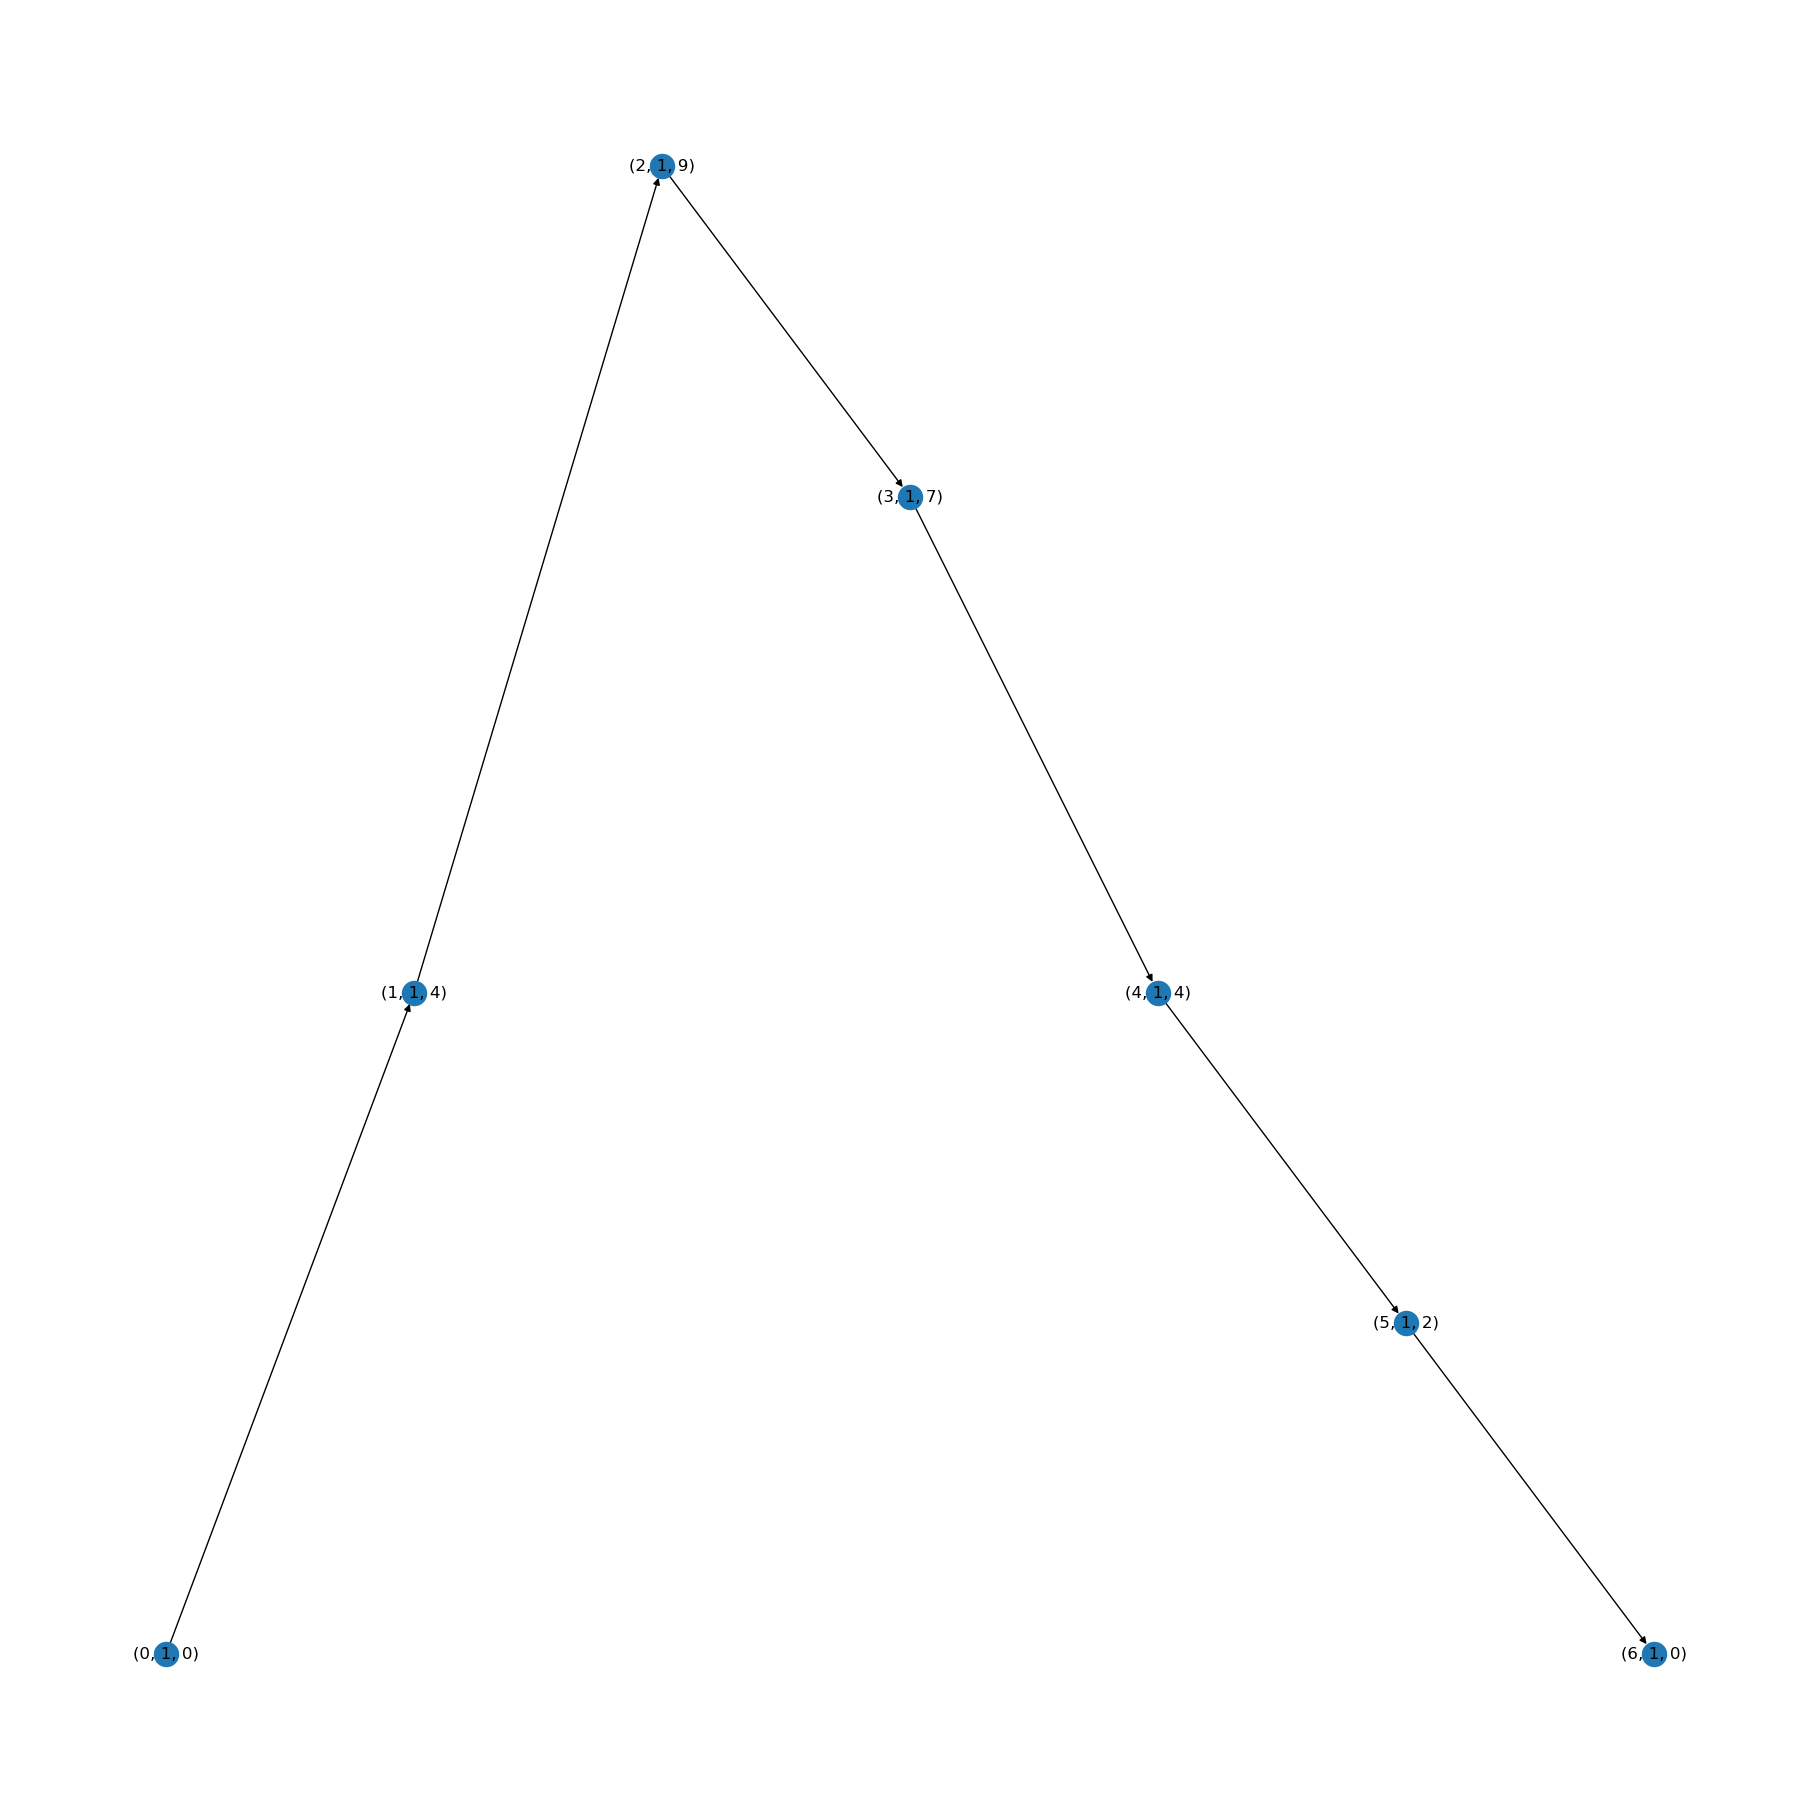

<Figure size 1800x1800 with 0 Axes>

In [9]:
import first

melody = [0,4,9,7,4,2,0]

melody_data = first.get_all_combos(melody, True)
# print("melody data:", melody_data)

ctp_graph = make_ctp_graph(melody_data)
# print("network:", ctp_graph)
visualize_network(ctp_graph)

cf_graph = make_cf_graph(melody)
# print("network:", cf_graph)
visualize_network(cf_graph)
